In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import GridSearchCV

In [4]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("15 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_category'] = df['mhw_category']

replace_category = {
    'Moderate': 0,
    'Strong': 1,
    'Severe': 2
}
df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_category'], axis=1)
y = shuffled_df_numeric['mhw_category']
X.shape, y.shape

mhw_category
0    605
1    185
2     31
Name: count, dtype: int64


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23368\521195506.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['mhw_category'] = df['mhw_category'].replace(replace_category)


((821, 15), (821,))

cross validation scores: [0.98181818 0.98170732 0.97560976 0.98780488 0.95731707]
0.9769 accuracy with a standard deviation of 0.0105
Accuracy: 97.58%
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       122
           1       1.00      0.89      0.94        37
           2       1.00      1.00      1.00         6

    accuracy                           0.98       165
   macro avg       0.99      0.96      0.98       165
weighted avg       0.98      0.98      0.98       165

[[122   0   0]
 [  4  33   0]
 [  0   0   6]]


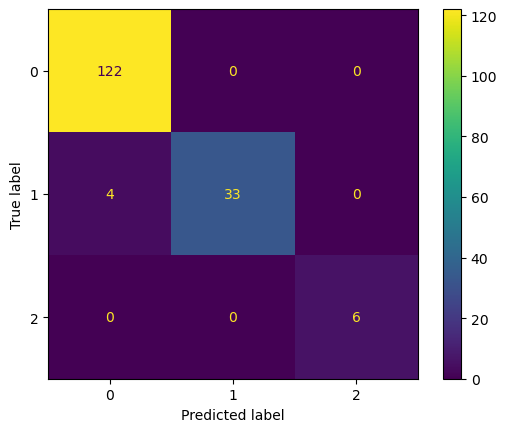

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
model = xgb.XGBClassifier(verbosity = 1, random_state = 42)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [6]:
# explicitly require this experimental feature
#from sklearn.experimental import enable_halving_search_cv # noqa
# now you can import normally from model_selection
#from sklearn.model_selection import HalvingGridSearchCV


param_grid = [
    {'learning_rate': [0.1, 0.3, 0.5],
     'gamma': [0, 0.5, 1],
     'max_depth': [3, 6, 10],
     'min_child_weight': [1, 3, 5 ],
     'subsample': [0.5, 1],
     'reg_lambda': [1, 2],
     'reg_alpha': [0, 1]
}]
grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
the best score was 0.9847906546379829
the best parameters were {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.170478,0.009102,0.008466,0.000791,0.0,0.1,3,1,0,1,0.5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.962121,0.992366,0.984733,0.984733,0.992366,0.983264,0.011109,17
1,0.168978,0.004778,0.008595,0.000940,0.0,0.1,3,1,0,1,1.0,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.962121,0.992366,0.977099,0.984733,0.992366,0.981737,0.011325,78
2,0.169961,0.003457,0.007885,0.000276,0.0,0.1,3,1,0,2,0.5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.962121,0.992366,0.984733,0.984733,0.992366,0.983264,0.011109,17
3,0.176388,0.011373,0.008751,0.000926,0.0,0.1,3,1,0,2,1.0,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.962121,0.992366,0.984733,0.984733,0.984733,0.981737,0.010244,43
4,0.172503,0.005251,0.008555,0.000772,0.0,0.1,3,1,1,1,0.5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.954545,0.992366,0.977099,0.984733,0.992366,0.980222,0.014031,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,0.119025,0.002409,0.009090,0.001538,1.0,0.5,10,5,0,2,1.0,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.939394,0.961832,0.969466,0.984733,0.992366,0.969558,0.018548,546
644,0.119418,0.004705,0.008079,0.000779,1.0,0.5,10,5,1,1,0.5,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.939394,0.969466,0.969466,0.992366,0.984733,0.971085,0.018159,491
645,0.115544,0.002777,0.008290,0.000756,1.0,0.5,10,5,1,1,1.0,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.939394,0.977099,0.961832,0.984733,0.984733,0.969558,0.017245,538
646,0.125185,0.003123,0.008607,0.000640,1.0,0.5,10,5,1,2,0.5,"{'gamma': 1, 'learning_rate': 0.5, 'max_depth'...",0.939394,0.969466,0.954198,0.977099,0.984733,0.964978,0.016298,625


In [7]:
# explicitly require this experimental feature
#from sklearn.experimental import enable_halving_search_cv # noqa
# now you can import normally from model_selection
#from sklearn.model_selection import HalvingGridSearchCV


param_grid = [
    {'learning_rate': [0.1, 0.2],
     'gamma': [0, 0.5, 1],
     'max_depth': [2, 3, 4],
     'min_child_weight': [2, 3, 4],
     'subsample': [0.9, 1],
     'reg_lambda': [1],
     'reg_alpha': [1, 2, 3]
}]
grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


the best score was 0.9847906546379829
the best parameters were {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 2, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.174029,0.053825,0.008672,0.001570,0.0,0.1,2,2,1,1,0.9,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.939394,0.961832,0.977099,0.977099,0.977099,0.966505,0.014789,208
1,0.139222,0.001668,0.008205,0.000328,0.0,0.1,2,2,1,1,1.0,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.946970,0.961832,0.977099,0.977099,0.984733,0.969547,0.013520,182
2,0.145923,0.003127,0.008738,0.000575,0.0,0.1,2,2,2,1,0.9,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.954545,0.961832,0.977099,0.992366,0.977099,0.972588,0.013214,129
3,0.160543,0.008281,0.007627,0.000519,0.0,0.1,2,2,2,1,1.0,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.946970,0.961832,0.977099,0.977099,0.977099,0.968020,0.012072,201
4,0.145630,0.006451,0.008104,0.000665,0.0,0.1,2,2,3,1,0.9,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.954545,0.961832,0.977099,0.992366,0.992366,0.975642,0.015475,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,0.164531,0.022285,0.010937,0.001688,1.0,0.2,4,4,1,1,1.0,"{'gamma': 1, 'learning_rate': 0.2, 'max_depth'...",0.939394,0.969466,0.969466,0.984733,0.992366,0.971085,0.018159,136
320,0.171343,0.007373,0.010062,0.001193,1.0,0.2,4,4,2,1,0.9,"{'gamma': 1, 'learning_rate': 0.2, 'max_depth'...",0.931818,0.977099,0.969466,0.969466,0.977099,0.964990,0.016933,222
321,0.161521,0.011405,0.009489,0.000429,1.0,0.2,4,4,2,1,1.0,"{'gamma': 1, 'learning_rate': 0.2, 'max_depth'...",0.924242,0.969466,0.946565,0.984733,0.969466,0.958894,0.021184,253
322,0.150843,0.008585,0.009639,0.000503,1.0,0.2,4,4,3,1,0.9,"{'gamma': 1, 'learning_rate': 0.2, 'max_depth'...",0.924242,0.961832,0.946565,0.969466,0.977099,0.955841,0.018751,272


cross validation scores: [0.98181818 0.97560976 0.98170732 0.98780488 0.96341463]
0.9781 accuracy with a standard deviation of 0.0083
Accuracy: 97.58%
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       122
           1       1.00      0.89      0.94        37
           2       1.00      1.00      1.00         6

    accuracy                           0.98       165
   macro avg       0.99      0.96      0.98       165
weighted avg       0.98      0.98      0.98       165

[[122   0   0]
 [  4  33   0]
 [  0   0   6]]


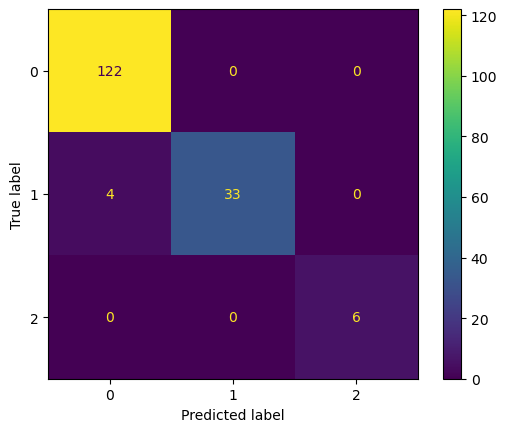

In [30]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
model = xgb.XGBClassifier(learning_rate = 0.1, max_depth = 3, min_child_weight = 2, reg_alpha = 1, 
                          subsample = 0.9,  verbosity = 1, reg_lambda = 1, random_state = 42)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)